# Implement LDA to build a Topic Model

Notes:

I am following along with my M08 LDA with SKLearn Notes and my M08 HW as I complete this section.

## Setup

### Import Libraries

In [368]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA, LatentDirichletAllocation as LDA

In [369]:
import plotly.express as px
import plotly.io as pio

sns.set_theme(style='white')
pio.renderers.default = 'vscode'

### Configuration

In [370]:
# specify OHCO and bags
OHCO = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']

bags = dict(
    SENTS = OHCO[:4],
    PARAS = OHCO[:3],
    CHAPS = OHCO[:2],
    BOOKS = OHCO[:1]
)

In [371]:
# set chapter as bag
bag = "CHAPS"

In [372]:
colors = "YlGnBu"

### Load Data

In [373]:
# load in tables
LIB = pd.read_csv('data/LIB.csv', sep='\t').set_index('book_id')
CORPUS = pd.read_csv('data/CORPUS.csv', sep='\t').set_index(OHCO)

## Prepare Data

### Build DOCS

SKLearn expects an F1 style corpus. So I create one from the annotated CORPUS table and keep only regular nouns.

In [374]:
# only regular nouns
DOCS = CORPUS[CORPUS.pos.str.match(r'^NNS?$')]\
    .groupby(bags[bag]).term_str\
    .apply(lambda x: ' '.join(x))\
    .to_frame('doc_str')

# DOCS

### Build Count Matrix (DTM)

Now I use SKLearn's CountVectorizer to convert the F1 corpus of chapters into a document-term vector space of word counts.

In [375]:
# instantiate CountVectorizer
count_engine = CountVectorizer(
    max_features=4000,
    max_df=.6, # drop terms appearing in more than 60% of chapters
    min_df=10, # drop terms appearing in fewer than 10 chapters (remove rare terms that would add noise without contributing to structure; hapax legomena etc)
    stop_words='english'
)

# fit the engine to the documents
# keep in mind that CountVectorizer outputs a sparse matrix
count_model = count_engine.fit_transform(DOCS['doc_str'])

# extract vocabulary array for use in PHI table
TERMS = count_engine.get_feature_names_out()
VOCAB = pd.DataFrame(index=TERMS)
VOCAB.index.name = 'term_str'

# convert sparse matrix into dense Pandas dataframe
DTM = pd.DataFrame(count_model.toarray(), index=DOCS.index, columns=TERMS) # convert to DataFrame to get DTM

DTM

aback  ability  absence  absurd  \
book_id                      chap_num                                    
giants-bread                 0             0        0        0       0   
                             1             0        0        0       0   
                             2             0        0        0       0   
                             3             0        0        1       0   
                             4             0        0        0       0   
...                                      ...      ...      ...     ...   
the-seven-dials-mystery      31            1        0        0       0   
                             32            0        0        0       0   
                             33            0        0        0       0   
                             34            0        0        0       0   
the-tragedy-at-marsdon-manor 1             2        0        0       0   

                                       accent  accident  accomplice  account  \
book_id                      chap_num                                          
giants-bread                 0              0         0           0        0   
                             1              0         0           0        0   
                             2              0         0           0        0   
                             3              0         0           0        0   
                             4              0         0           0        0   
...                                       ...       ...         ...      ...   
the-seven-dials-mystery      31             0         0           0        0   
                             32             0         0           0        0   
                             33             0         1           0        0   
                             34             0         0           0        0   
the-tragedy-at-marsdon-manor 1              0         1           0        0   

                                       accounts  accuracy  ...  wound  wrist  \
book_id                      chap_num                      ...                 
giants-bread                 0                0         0  ...      0      0   
                             1                0         0  ...      0      0   
                             2                0         0  ...      0      0   
                             3                0         0  ...      0      0   
                             4                0         0  ...      0      1   
...                                         ...       ...  ...    ...    ...   
the-seven-dials-mystery      31               0         0  ...      0      0   
                             32               0         0  ...      0      0   
                             33               0         0  ...      0      0   
                             34               0         0  ...      0      0   
the-tragedy-at-marsdon-manor 1                0         0  ...      1      0   

                                       writing  yards  yawn  year  years  yes  \
book_id                      chap_num                                           
giants-bread                 0               0      0     0     0      0    0   
                             1               0      0     0     0      4    0   
                             2               0      0     0     0      0    0   
                             3               0      0     0     0      2    0   
                             4               0      0     0     0      1    0   
...                                        ...    ...   ...   ...    ...  ...   
the-seven-dials-mystery      31              0      0     0     0      0    0   
                             32              0      0     0     0      0    0   
                             33              0      0     0     0      0    0   
                             34              1      0     0     0      0    0   
the-tragedy-at-marsdon

## Fit LDA Model

In [376]:
# set parameters
n_components = 15 # number of topics
random_state = 36
n_top_terms = 5

In [377]:
# instantiate LDA model
lda_engine = LDA(
    n_components = n_components,
    random_state = random_state
)

# fit LDA model to the DTM and generate document-topic distribution
topic_dist = lda_engine.fit_transform(DTM)

# topic_dist

## Extract Results

### THETA (Document-Topic Matrix)

THETA: given this document, what is the probability distribution over topics? Each row is a document, each column is a topic, each cell is p(topic | document).

In [378]:
# create THETA (Document-Topic Matrix)
THETA = pd.DataFrame(
    topic_dist, # contains document-topic probabilities
    index = DOCS.index
)

# THETA.index.name = 'para_id' # remove this so THETA gets multindex from docs?
THETA.columns.name = 'topic_id'

# THETA

In [379]:
# THETA.sample(10).T.style.background_gradient(cmap=colors, axis=None)

### PHI (Topic-Word Matrix)

PHI: given this topic, what is the probability distribution over words? Each row is a topic, each column is a term, each cell is p(word | topic).

In [380]:
# create PHI (Topic-Word Matrix)
PHI = pd.DataFrame(
    lda_engine.components_, # contains raw pseudo-counts of words to objects
    columns = TERMS
)

PHI.index.name = 'topic_id'
PHI.columns.name = 'term_str'

# PHI

In [381]:
# PHI.T.sample(10).T.style.background_gradient(cmap=colors, axis=None)

### TOPICS (Top Terms per Topic)

Creating a TOPICS table with top 5 words per topic.

In [382]:
TOPICS = PHI.stack().groupby('topic_id').apply(
    lambda x : ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str)).to_frame("top_terms")

TOPICS

,top_terms
topic_id,
0,tea hospital home dear ladies
1,window cabin right light story
2,train compartment maid platform hotel
3,uncle money men story somebody
4,mother father boy child girl
5,friend police ami jewels lady
6,letters sir letter car look
7,crime murder friend evidence letter
8,girl secretary war car fellow


What I tried:

1. max_features=4000, max_df=0.9, min_df=10, n_components = 20
- have a lot of generic physical and spatial vocabulary (door, room, head, eyes, hand, face) in T0, T2, T7, T14, and T15

2. I am going to lower max_df from 0.9 to 0.6 to see if lowering the threshold will eliminate some of these more generic terms from the vocab.
- This has gotten better. I've noticed some french showing up in T5. I am going to drop to n_components = 15 now.

## Explore

### Inspect Topics

In [383]:
TOPICS

,top_terms
topic_id,
0,tea hospital home dear ladies
1,window cabin right light story
2,train compartment maid platform hotel
3,uncle money men story somebody
4,mother father boy child girl
5,friend police ami jewels lady
6,letters sir letter car look
7,crime murder friend evidence letter
8,girl secretary war car fellow


In [384]:
TOPICS['doc_weight_sum'] = THETA.sum()
TOPICS['doc_weight_mean'] = THETA.mean()

In [385]:
TOPICS.sort_values('doc_weight_mean', ascending=False).head(5)

,top_terms,doc_weight_sum,doc_weight_mean
topic_id,,,
9,girl friend doctor lady death,82.216030,0.252972
7,crime murder friend evidence letter,43.854817,0.134938
1,window cabin right light story,30.343172,0.093364
13,sir inspector window table minutes,27.976134,0.086080
8,girl secretary war car fellow,26.869722,0.082676


Topic interpretations:
- T9: "womens' sphere", likely related to Marple
- T: not super clear
- T2: Railway travel / travel
- 

### Explore Topic Distributions by Feature (Book/Sleuth/Work Type)

In [386]:
THETAX = THETA.join(LIB[['sleuth', 'work_type', 'genre']], on='book_id').reset_index().set_index(['book_id', 'chap_num'])
THETAX['primary_genre'] = THETAX['genre'].str.split('|').str[0]

THETAX

0         1         2         3  \
book_id                      chap_num                                           
giants-bread                 0         0.000385  0.000385  0.000385  0.994605   
                             1         0.000337  0.000337  0.000337  0.000337   
                             2         0.000570  0.000570  0.000570  0.000570   
                             3         0.000285  0.126861  0.000285  0.000285   
                             4         0.033532  0.000231  0.000231  0.032820   
...                                         ...       ...       ...       ...   
the-seven-dials-mystery      31        0.000551  0.000551  0.000551  0.000551   
                             32        0.000784  0.000784  0.000784  0.000784   
                             33        0.000242  0.644100  0.000242  0.000242   
                             34        0.001961  0.001961  0.001961  0.001961   
the-tragedy-at-marsdon-manor 1         0.000159  0.000159  0.000159  0.000159   

                                              4         5         6         7  \
book_id                      chap_num                                           
giants-bread                 0         0.000385  0.000385  0.000385  0.000385   
                             1         0.995286  0.000337  0.000337  0.000337   
                             2         0.000570  0.000570  0.000570  0.000570   
                             3         0.869435  0.000285  0.000285  0.000285   
                             4         0.930870  0.000231  0.000231  0.000231   
...                                         ...       ...       ...       ...   
the-seven-dials-mystery      31        0.143461  0.000551  0.000551  0.000551   
                             32        0.118865  0.000784  0.000784  0.000784   
                             33        0.000242  0.000242  0.000242  0.000242   
                             34        0.001961  0.179750  0.001961  0.269863   
the-tragedy-at-marsdon-manor 1         0.000159  0.000159  0.000159  0.227627   

                                              8         9        10        11  \
book_id                      chap_num                                           
giants-bread                 0         0.000385  0.000385  0.000385  0.000385   
                             1         0.000337  0.000337  0.000337  0.000337   
                             2         0.000570  0.000570  0.992023  0.000570   
                             3         0.000285  0.000285  0.000285  0.000285   
                             4         0.000231  0.000231  0.000231  0.000231   
...                                         ...       ...       ...       ...   
the-seven-dials-mystery      31        0.000551  0.849377  0.000551  0.000551   
                             32        0.000784  0.671626  0.000784  0.000784   
                             33        0.000242  0.352748  0.000242  0.000242   
                             34        0.526858  0.001961  0.001961  0.001961   
the-tragedy-at-marsdon-manor 1         0.000159  0.709038  0.000159  0.000159   

                                             12        13        14  \
book_id                      chap_num                                 
giants-bread                 0         0.000385  0.000385  0.000385   
                             1         0.000337  0.000337  0.000337   
                             2         0.000570  0.000570  0.000570   
                             3         0.000285  0.000285  0.000285   
                             4         0.000231  0.000231  0.000231   
...                                         ...       ...       ...   
the-seven-dials-mystery      31        0.000551  0.000551  0.000551   
                             32        0.200098  0.000784  0.000784   
                             33        0.000242  0.000242  0.000242   
                             34        0.001961  0.001961  0.001961   
the-tragedy-at-marsdon-manor 1  

In [387]:
# groupby book_id ("how much does this book talk about this topic?")
TOPIC_BOOK = THETAX.groupby('book_id').mean(numeric_only=True)
TOPIC_BOOK.T.style.background_gradient(axis=0, cmap="YlGnBu")

book_id,giants-bread,the-adventure-of-the-cheap-flat,the-adventure-of-the-egyptian-tomb,the-adventure-of-the-italian-nobleman,the-adventure-of-the-western-star,the-big-four,the-case-of-the-missing-will,the-disappearance-of-mr-davenheim,the-jewel-robbery-at-the-grand-metropolitan,the-kidnapped-prime-minister,the-man-in-the-brown-suit,the-million-dollar-bond-robbery,the-murder-at-the-vicarage,the-murder-of-roger-ackroyd,the-murder-on-the-links,the-mysterious-affair-at-styles,the-mystery-of-hunters-lodge,the-mystery-of-the-blue-train,the-secret-adversary,the-secret-of-chimneys,the-seven-dials-mystery,the-tragedy-at-marsdon-manor
0,0.028241,0.000155,0.000144,0.000157,0.000094,0.000254,0.000183,0.000127,0.000127,0.000110,0.024224,0.000233,0.049085,0.011521,0.000334,0.001477,0.000147,0.000476,0.004167,0.004251,0.015817,0.000159
1,0.009127,0.168278,0.000144,0.000157,0.000094,0.006414,0.000183,0.000127,0.000127,0.000110,0.251787,0.248826,0.036967,0.012924,0.010540,0.000188,0.000147,0.050012,0.001810,0.310569,0.203488,0.000159
2,0.000891,0.000155,0.000144,0.000157,0.000094,0.007723,0.000183,0.000127,0.000127,0.000110,0.106542,0.000233,0.008471,0.000338,0.066903,0.003619,0.000147,0.192296,0.007499,0.002350,0.000477,0.000159
3,0.038156,0.000155,0.070824,0.000157,0.000094,0.009991,0.997443,0.000127,0.000127,0.000110,0.027279,0.066277,0.035183,0.014978,0.000334,0.000188,0.000147,0.000476,0.000340,0.000367,0.001672,0.000159
4,0.445839,0.000155,0.000144,0.000157,0.037502,0.000254,0.000183,0.000127,0.000127,0.000110,0.024035,0.000233,0.051705,0.037747,0.101689,0.066084,0.000147,0.107021,0.012358,0.005876,0.061581,0.000159
5,0.000272,0.246366,0.000144,0.376671,0.961270,0.057469,0.000183,0.142039,0.998226,0.102409,0.000431,0.242616,0.023418,0.000821,0.028865,0.035567,0.091778,0.150205,0.017711,0.058538,0.010394,0.000159
6,0.000272,0.000155,0.000144,0.000157,0.000094,0.001847,0.000183,0.000127,0.000127,0.000110,0.032182,0.000233,0.022308,0.000338,0.000334,0.000188,0.000147,0.017066,0.009725,0.017006,0.002525,0.000159
7,0.000272,0.000155,0.255770,0.105936,0.000094,0.132979,0.000183,0.352192,0.000127,0.147934,0.039742,0.096374,0.142609,0.176882,0.475341,0.269708,0.393264,0.239350,0.022145,0.076038,0.018593,0.227627
8,0.050374,0.000155,0.000144,0.000157,0.000094,0.015706,0.000183,0.000127,0.000127,0.311471,0.301484,0.112202,0.002662,0.020025,0.043226,0.000188,0.000147,0.043986,0.150739,0.089765,0.087354,0.000159
9,0.079149,0.583500,0.618009,0.284809,0.000094,0.652265,0.000183,0.504248,0.000127,0.436974,0.117746,0.203726,0.197842,0.207656,0.247248,0.272496,0.350493,0.055486,0.537042,0.116086,0.487021,0.709038


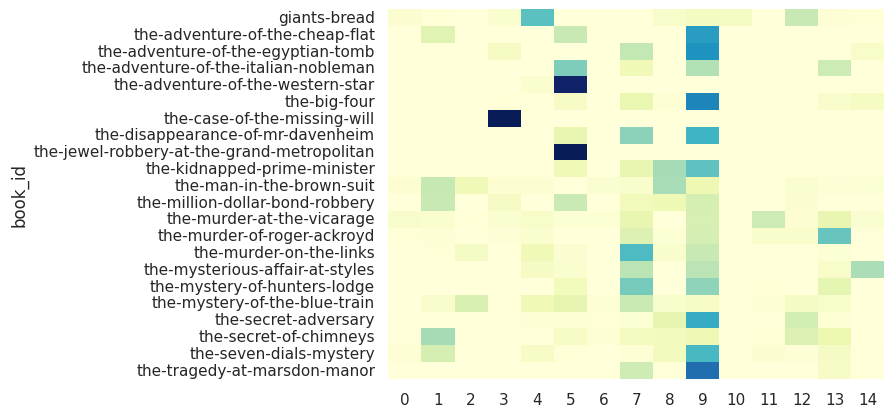

In [388]:
sns.heatmap(TOPIC_BOOK, cmap="YlGnBu", cbar=None)
plt.show()

In [389]:
# groupby sleuth ("how much do works with this sleuth talk about this topic?")
THETAX['sleuth'] = THETAX['sleuth'].fillna('None') # deal with giants bread
TOPIC_SLEUTH = THETAX.groupby('sleuth').mean(numeric_only=True)
TOPIC_SLEUTH.T.style.background_gradient(axis=0, cmap="YlGnBu")

sleuth,Colonel Race,Hercule Poirot,Miss Jane Marple,None,Superintendent Battle,Tommy and Tuppence
0,0.024224,0.002729,0.049085,0.028241,0.010301,0.004167
1,0.251787,0.022411,0.036967,0.009127,0.254557,0.001810
2,0.106542,0.067615,0.008471,0.000891,0.001370,0.007499
3,0.027279,0.013149,0.035183,0.038156,0.001050,0.000340
4,0.024035,0.064826,0.051705,0.445839,0.035014,0.012358
5,0.000431,0.081928,0.023418,0.000272,0.033355,0.017711
6,0.032182,0.005039,0.022308,0.000272,0.009432,0.009725
7,0.039742,0.257003,0.142609,0.000272,0.045990,0.022145
8,0.301484,0.030411,0.002662,0.050374,0.088504,0.150739
9,0.117746,0.251892,0.197842,0.079149,0.310114,0.537042


In [390]:
# sns.heatmap(TOPIC_SLEUTH, cmap="YlGnBu", cbar=None)
# plt.show()

In [391]:
# groupby work type ("how much do works of this type talk about this topic?")
TOPIC_WORK = THETAX.groupby('work_type').mean(numeric_only=True)
TOPIC_WORK.T.style.background_gradient(axis=0, cmap="YlGnBu")

work_type,novel,short_story
0,0.014133,0.000149
1,0.095302,0.038032
2,0.043110,0.000149
3,0.012525,0.103238
4,0.085001,0.003549
5,0.035635,0.287442
6,0.011070,0.000149
7,0.134634,0.143605
8,0.084219,0.038633
9,0.250079,0.335564


In [392]:
# sns.heatmap(TOPIC_WORK, cmap="YlGnBu", cbar=None)
# plt.show()

In [393]:
# groupby primary genre ("how much do works of this primary genre talk about this topic?")
TOPIC_GENRE = THETAX.groupby('primary_genre').mean(numeric_only=True)
TOPIC_GENRE.T.style.background_gradient(axis=0, cmap="YlGnBu")

primary_genre,Detective,Espionage,Murder Mystery,Romance
0,0.000254,0.008408,0.015355,0.028241
1,0.006414,0.176582,0.072632,0.009127
2,0.007723,0.003261,0.071016,0.000891
3,0.009991,0.000831,0.020131,0.038156
4,0.000254,0.028024,0.060659,0.445839
5,0.057469,0.028529,0.057757,0.000272
6,0.001847,0.009522,0.013813,0.000272
7,0.132979,0.038633,0.205553,0.000272
8,0.015706,0.107704,0.081533,0.050374
9,0.652265,0.380124,0.176350,0.079149


In [394]:
# sns.heatmap(TOPIC_GENRE, cmap="YlGnBu", cbar=None)
# plt.show()

## LDA + PCA Visualization (4)

Apply PCA to the THETA table and plot the topics in the space opened by the first two components.

Size the points based on the mean document weight of each topic (using the THETA table).

Color the points basd on a metadata feature from the LIB table.

Provide a brief interpretation of what you see.

(INSERT IMAGE HERE)

(INSERT INTERPRETATION HERE)

## Save Outputs

In [395]:
# # save the updated VOCAB table to csv (replace the existing one created by 03-VOCAB.ipynb)
# VOCAB.to_csv('data/VOCAB.csv', sep='\t', index=True)

# # save the BOW table to csv
# BOW_chaps.to_csv('data/BOW_chaps.csv', sep='\t', index=True)

# # save the DTM table to csv
# DTM.to_csv('data/DTM.csv', sep='\t', index=True)

# # save the TFIDF table to csv
# TFIDF.to_csv('data/TFIDF.csv', sep='\t', index=True)

# # save the TFIDF_L2 table to csv
# TFIDF_L2.to_csv('data/TFIDF_L2.csv', sep='\t', index=True)